In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file="Exoplanet_6059_with_derived_spectral_columns_Finale.xlsx"
df=pd.read_excel(file)

df.head()

,Planet Name,Host Name,Default Flag,Number of Stars,Number of Planets,Discovery Method,Soltype,Controversial Flag,Orbital Period [Days],Orbit Semi-Major Axis [au],...,Stellar Effective Temperature [K],Stellar Radius [Solar Radius],Stellar Mass [Solar mass],Stellar Surface Gravity [log10(cm/s**2)],Distance [pc],Derived Spectral Subclass,Estimated Luminosity Class,Derived Spectral Type,Final Spectral Type,Final Spectral Type Source
0,24 Sex b,24 Sex,1,1,2,Radial Velocity,Published Confirmed,0,452.8,1.333,...,5098.0,4.900000,1.540,3.50000,72.069100,K0,IV,K0 IV,K0 IV,Observed
1,24 Sex c,24 Sex,1,1,2,Radial Velocity,Published Confirmed,0,883.0,2.080,...,5098.0,4.900000,1.540,3.50000,72.069100,K0,IV,K0 IV,K0 IV,Observed
2,2MASS J01225093-2439505 b,2MASS J01225093-2439505,1,1,1,Imaging,Published Confirmed,0,NaN,52.000,...,3530.0,0.366450,0.400,4.85804,33.828100,M1,V,M1 V,M3.5 V,Observed
3,2MASS J04414489+2301513 b,2MASS J04414489+2301513,1,1,1,Imaging,Published Confirmed,0,NaN,15.000,...,2936.0,0.231916,0.019,5.01181,120.423987,M5,V,M5 V,M8.5,Observed
4,47 UMa b,47 UMa,1,1,3,Radial Velocity,Published Confirmed,0,1078.0,2.100,...,5872.0,1.213340,1.060,4.29541,13.796700,G1,V,G1 V,G0V,Observed


In [3]:
df.shape

(6059, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6059 entries, 0 to 6058
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Planet Name                               6059 non-null   object 
 1   Host Name                                 6059 non-null   object 
 2   Default Flag                              6059 non-null   int64  
 3   Number of Stars                           6059 non-null   int64  
 4   Number of Planets                         6059 non-null   int64  
 5   Discovery Method                          6059 non-null   object 
 6   Soltype                                   6059 non-null   object 
 7   Controversial Flag                        6059 non-null   int64  
 8   Orbital Period [Days]                     5739 non-null   float64
 9   Orbit Semi-Major Axis [au]                5746 non-null   float64
 10  Planet Radius [Earth Radius]        

In [5]:
df.isna().sum().sort_values(ascending=False)

Star Spectral Type                          2203
Equilibrium Temperature [K]                 1504
Orbital Period [Days]                        320
Orbit Semi-Major Axis [au]                   313
Stellar Surface Gravity [log10(cm/s**2)]     305
Stellar Radius [Solar Radius]                299
Estimated Luminosity Class                   293
Derived Spectral Type                        281
Derived Spectral Subclass                    281
Stellar Effective Temperature [K]            281
Final Spectral Type                          243
Final Spectral Type Source                   243
Planet Radius [Earth Radius]                  44
Distance [pc]                                 27
Planet Mass or Mass*sin(i) [Earth Mass]       26
Stellar Mass [Solar mass]                      5
Host Name                                      0
Controversial Flag                             0
Soltype                                        0
Discovery Method                               0
Number of Planets   

In [6]:
df.describe()

,Default Flag,Number of Stars,Number of Planets,Controversial Flag,Orbital Period [Days],Orbit Semi-Major Axis [au],Planet Radius [Earth Radius],Planet Mass or Mass*sin(i) [Earth Mass],Equilibrium Temperature [K],Stellar Effective Temperature [K],Stellar Radius [Solar Radius],Stellar Mass [Solar mass],Stellar Surface Gravity [log10(cm/s**2)],Distance [pc]
count,6059.0,6059.000000,6059.000000,6059.0,5.739000e+03,5746.000000,6015.000000,6033.000000,4555.000000,5778.000000,5760.000000,6054.000000,5754.000000,6032.000000
mean,1.0,1.101172,1.764813,0.0,7.456112e+04,15.831220,5.818576,389.984248,915.129095,5386.464373,1.498543,0.937992,4.384246,709.831041
std,0.0,0.337240,1.152449,0.0,5.308978e+06,351.669097,5.365847,1124.751498,464.236126,1626.756603,3.929749,0.408886,0.437892,1197.601936
min,1.0,1.000000,1.000000,0.0,9.070629e-02,0.004400,0.309800,0.020000,34.000000,415.000000,0.011500,0.009400,0.541000,1.301190
25%,1.0,1.000000,1.000000,0.0,4.340708e+00,0.052225,1.820500,4.160000,568.000000,4914.000000,0.770000,0.771000,4.293000,104.472250
50%,1.0,1.000000,1.000000,0.0,1.103189e+01,0.101450,2.838000,9.110000,822.000000,5551.000000,0.953000,0.940000,4.453000,384.694000
75%,1.0,1.000000,2.000000,0.0,3.866175e+01,0.298528,11.900000,181.000000,1166.000000,5900.000000,1.245750,1.089500,4.579000,838.595000
max,1.0,4.000000,8.000000,0.0,4.020000e+08,19000.000000,87.205870,9534.852210,4050.000000,57000.000000,88.475000,10.940000,8.070000,8500.000000


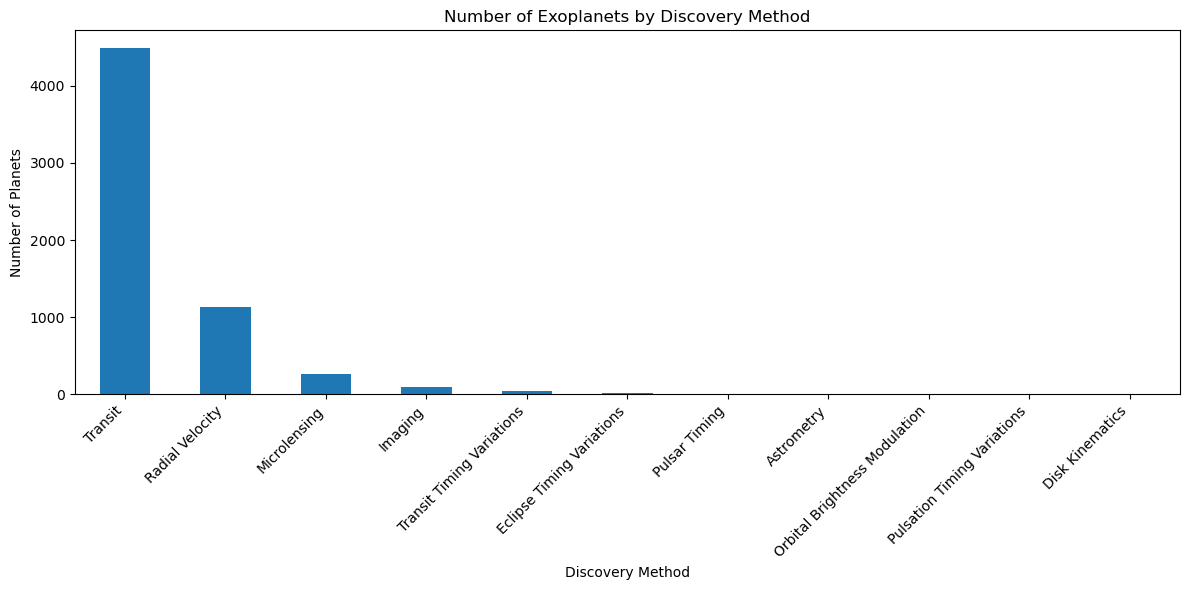

In [7]:
#Planets by Discovery Method
discovery_counts=df["Discovery Method"].value_counts()

discovery_counts.plot(kind="bar", figsize=(12,6))
plt.title("Number of Exoplanets by Discovery Method")
plt.xlabel("Discovery Method")
plt.ylabel("Number of Planets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

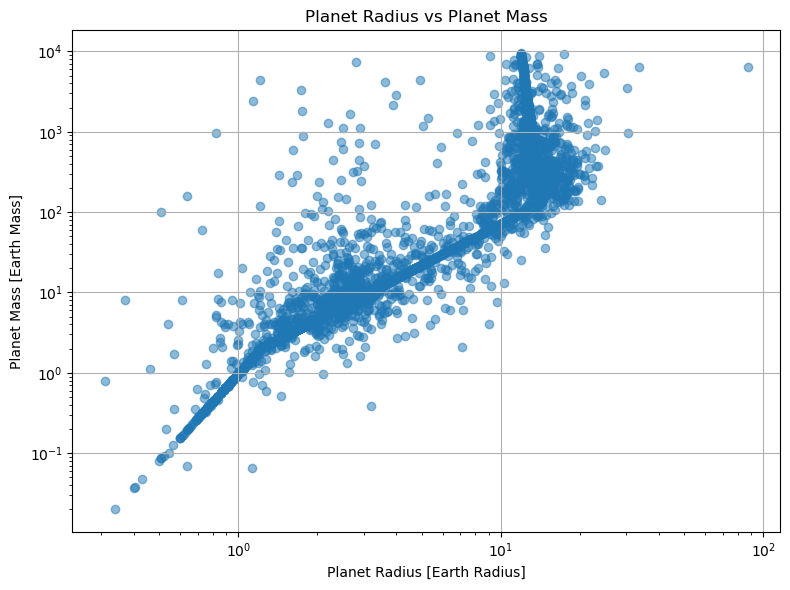

In [8]:
#Planet radius vs planet mass
plt.figure(figsize=(8,6))
plt.scatter(
    df["Planet Radius [Earth Radius]"],
    df["Planet Mass or Mass*sin(i) [Earth Mass]"],
    alpha=0.5
)
plt.title("Planet Radius vs Planet Mass")
plt.xlabel("Planet Radius [Earth Radius]")
plt.ylabel("Planet Mass [Earth Mass]")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

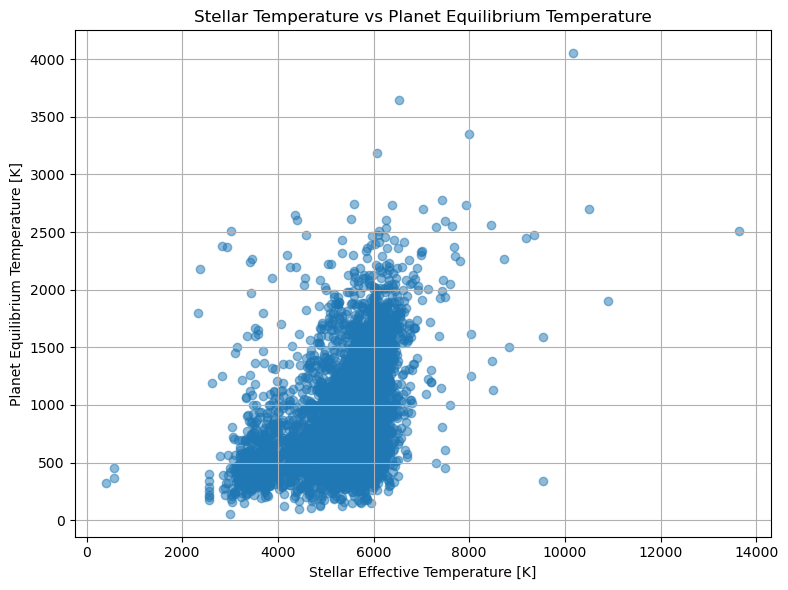

In [9]:
#Stellar temperature vs planet equilibrium temperature
plt.figure(figsize=(8,6))
plt.scatter(
    df["Stellar Effective Temperature [K]"],
    df["Equilibrium Temperature [K]"],
    alpha=0.5
)
plt.title("Stellar Temperature vs Planet Equilibrium Temperature")
plt.xlabel("Stellar Effective Temperature [K]")
plt.ylabel("Planet Equilibrium Temperature [K]")
plt.grid(True)
plt.tight_layout()
plt.show()

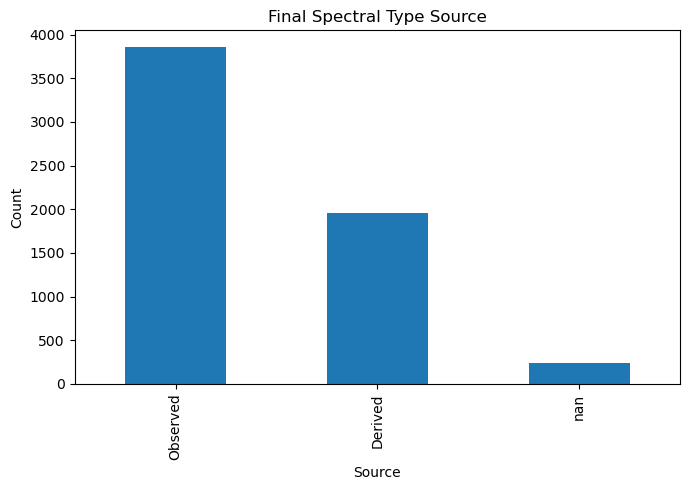

In [10]:
#Final spectral type source: observed vs derived
source_counts=df["Final Spectral Type Source"].value_counts(dropna=False)

source_counts.plot(kind="bar", figsize=(7,5))
plt.title("Final Spectral Type Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

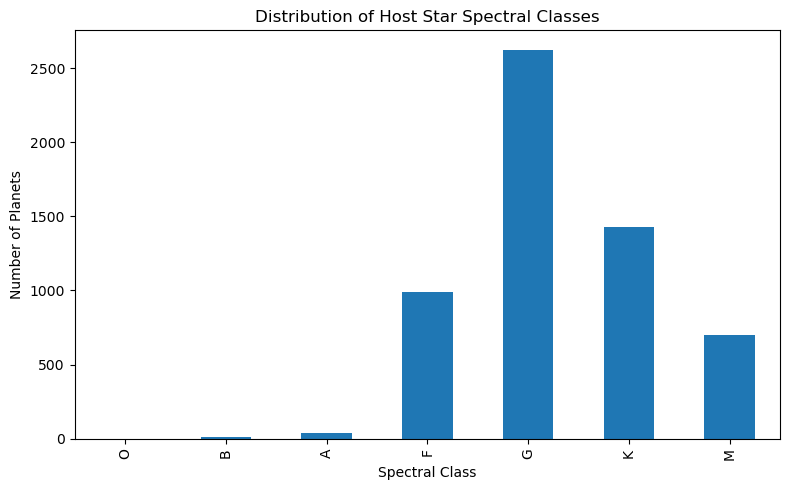

In [11]:
#Spectral class distribution
df["Spectral Letter"]=df["Final Spectral Type"].astype(str).str[0]

spectral_order=["O", "B", "A", "F", "G", "K", "M"]
spectral_counts=df["Spectral Letter"].value_counts().reindex(spectral_order)

spectral_counts.plot(kind="bar", figsize=(8,5))
plt.title("Distribution of Host Star Spectral Classes")
plt.xlabel("Spectral Class")
plt.ylabel("Number of Planets")
plt.tight_layout()
plt.show()

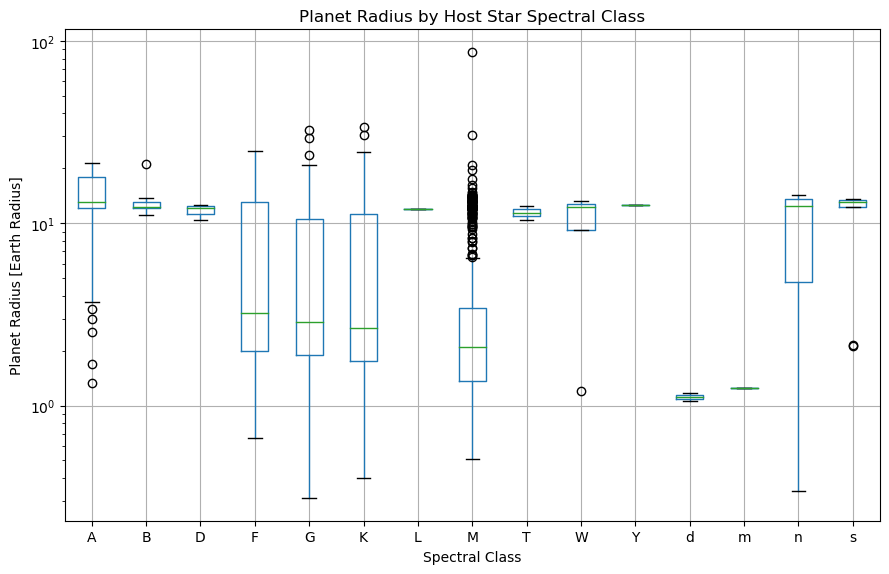

In [12]:
#Planet radius by spectral class
df.boxplot(
    column="Planet Radius [Earth Radius]",
    by="Spectral Letter",
    figsize=(9,6)
)

plt.title("Planet Radius by Host Star Spectral Class")
plt.suptitle("")
plt.xlabel("Spectral Class")
plt.ylabel("Planet Radius [Earth Radius]")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Stellar Luminosity from Radius and Temperature
##L/L.=(R/R.)^2(T/5778)4

In [13]:
#Clean columns
df["Stellar Effective Temperature [K]"]=pd.to_numeric(
    df["Stellar Effective Temperature [K]"], errors="coerce"
)

df["Stellar Radius [Solar Radius]"]=pd.to_numeric(
    df["Stellar Radius [Solar Radius]"], errors="coerce"
)

#Derive luminosity in solar units
df["Stellar Luminosity [Solar]"]=(
    df["Stellar Radius [Solar Radius]"]**2 *
    (df["Stellar Effective Temperature [K]"] / 5778)**4
)

# Get spectral class letter
df["Spectral Class"]=df["Final Spectral Type"].astype(str).str[0]

# Keep usable rows
hr=df.dropna(subset=[
    "Stellar Effective Temperature [K]",
    "Stellar Luminosity [Solar]"
])

hr=hr[
    (hr["Stellar Effective Temperature [K]"] > 0) &
    (hr["Stellar Luminosity [Solar]"] > 0)
]

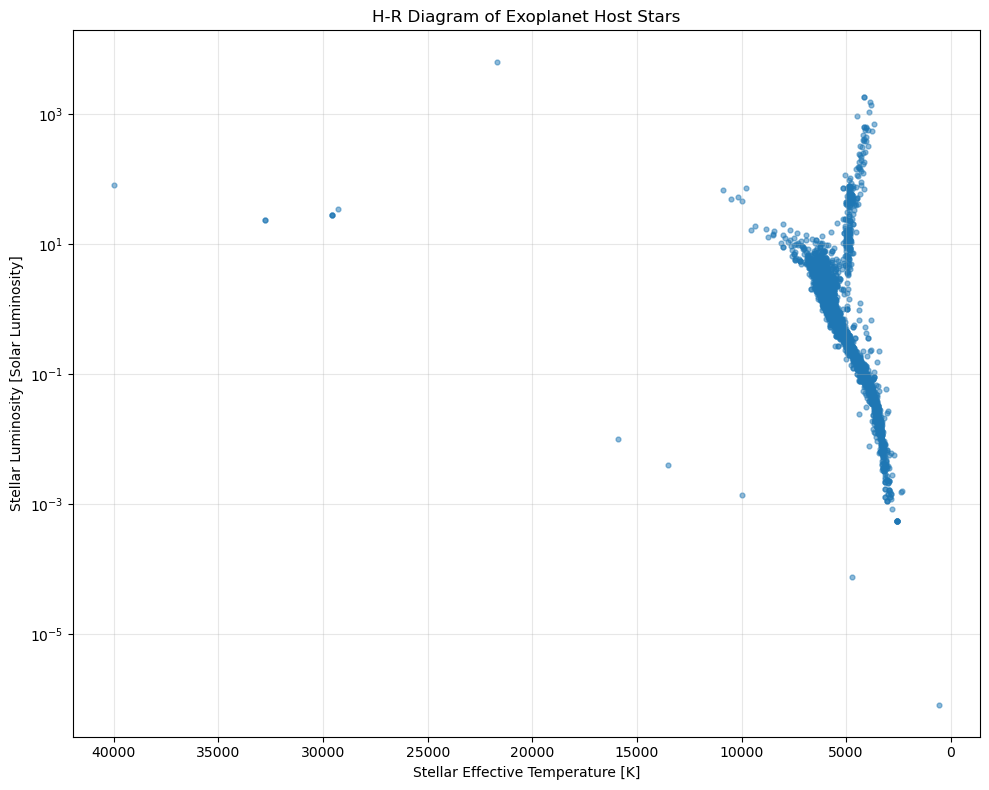

In [14]:
plt.figure(figsize=(10, 8))

plt.scatter(
    hr["Stellar Effective Temperature [K]"],
    hr["Stellar Luminosity [Solar]"],
    alpha=0.5,
    s=12
)

plt.xscale("linear")
plt.yscale("log")

plt.gca().invert_xaxis()

plt.title("H-R Diagram of Exoplanet Host Stars")
plt.xlabel("Stellar Effective Temperature [K]")
plt.ylabel("Stellar Luminosity [Solar Luminosity]")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

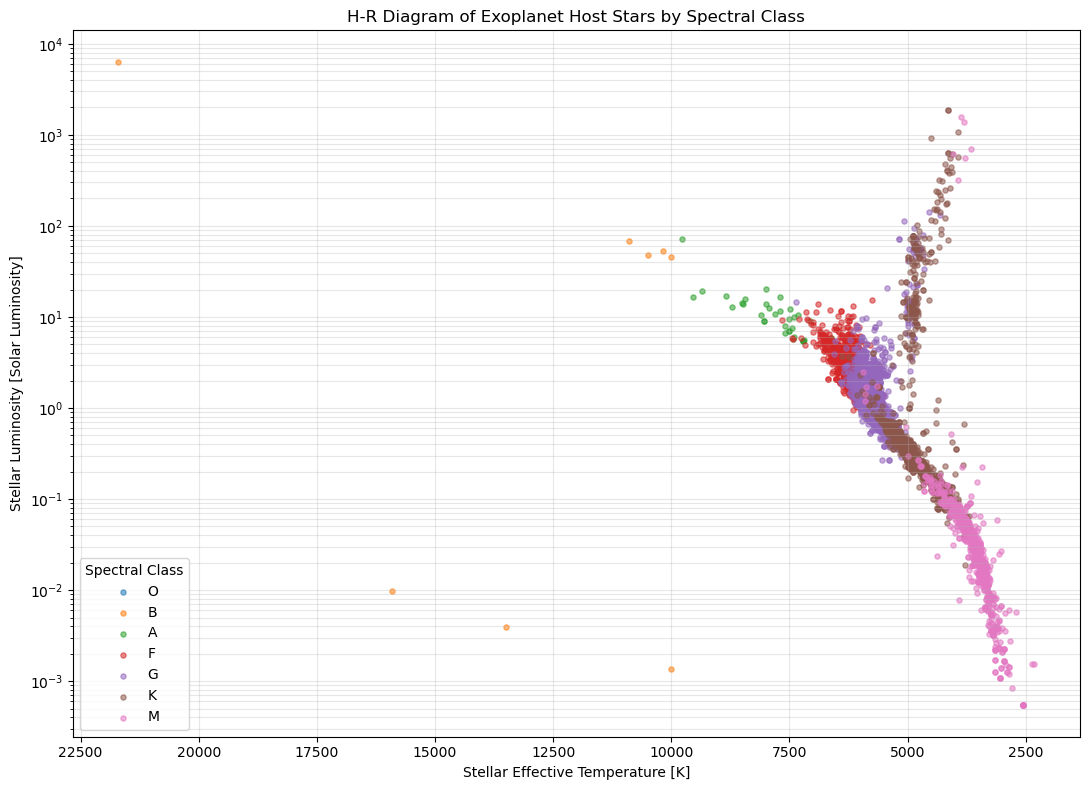

In [15]:
spectral_order=["O", "B", "A", "F", "G", "K", "M"]

plt.figure(figsize=(11, 8))

for spectral in spectral_order:
    subset=hr[hr["Spectral Class"]==spectral]
    plt.scatter(
        subset["Stellar Effective Temperature [K]"],
        subset["Stellar Luminosity [Solar]"],
        alpha=0.55,
        s=14,
        label=spectral)

plt.yscale("log")
plt.gca().invert_xaxis()

plt.title("H-R Diagram of Exoplanet Host Stars by Spectral Class")
plt.xlabel("Stellar Effective Temperature [K]")
plt.ylabel("Stellar Luminosity [Solar Luminosity]")

plt.legend(title="Spectral Class")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

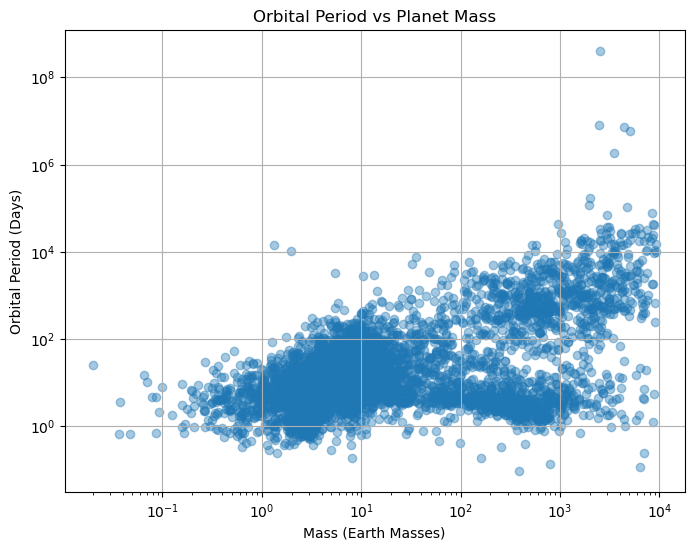

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Planet Mass or Mass*sin(i) [Earth Mass]"],
    df["Orbital Period [Days]"],
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Orbital Period vs Planet Mass")
plt.xlabel("Mass (Earth Masses)")
plt.ylabel("Orbital Period (Days)")

plt.grid(True)
plt.show()

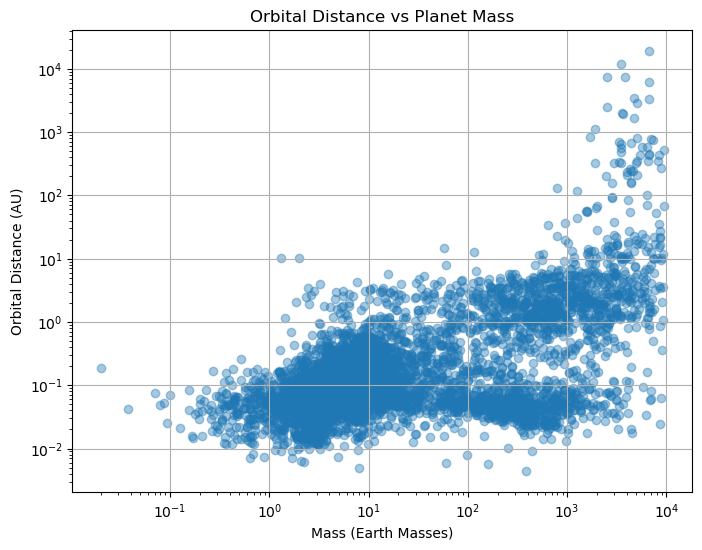

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Planet Mass or Mass*sin(i) [Earth Mass]"],
    df["Orbit Semi-Major Axis [au]"],
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Orbital Distance vs Planet Mass")
plt.xlabel("Mass (Earth Masses)")
plt.ylabel("Orbital Distance (AU)")

plt.grid(True)
plt.show()

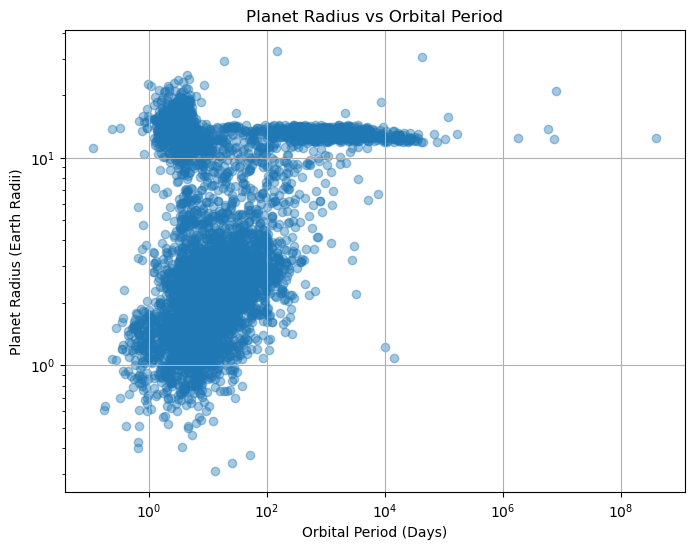

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Orbital Period [Days]"],
    df["Planet Radius [Earth Radius]"],
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Planet Radius vs Orbital Period")
plt.xlabel("Orbital Period (Days)")
plt.ylabel("Planet Radius (Earth Radii)")

plt.grid(True)
plt.show()

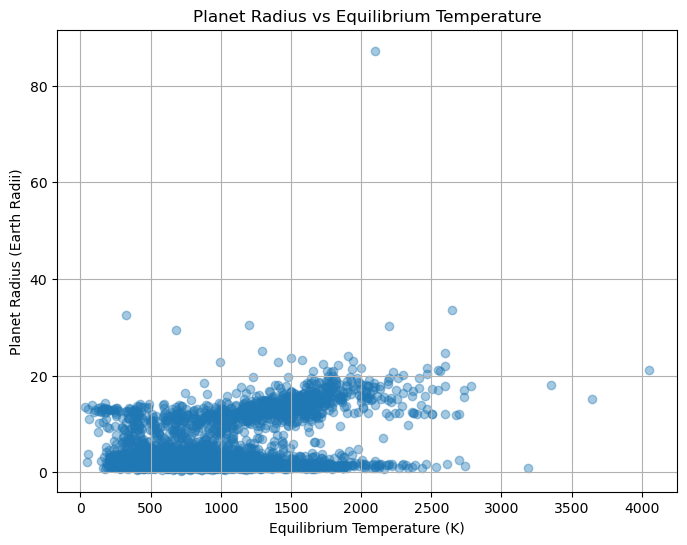

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Equilibrium Temperature [K]"],
    df["Planet Radius [Earth Radius]"],
    alpha=0.4
)

plt.title("Planet Radius vs Equilibrium Temperature")
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius (Earth Radii)")

plt.grid(True)
plt.show()

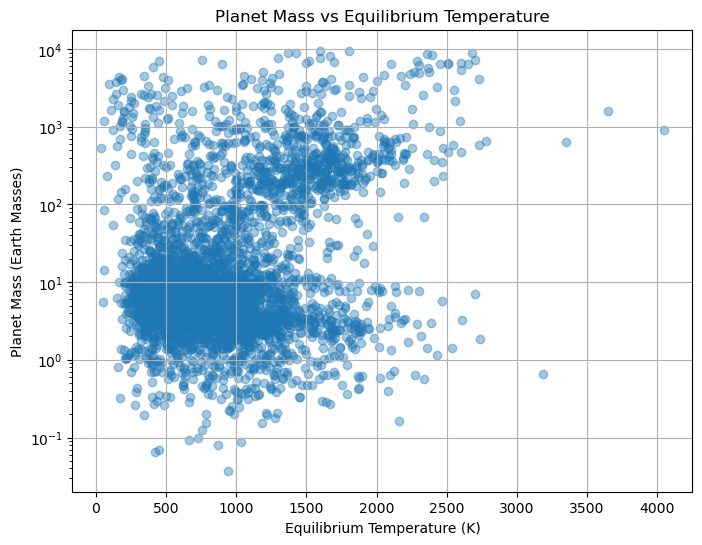

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Equilibrium Temperature [K]"],
    df["Planet Mass or Mass*sin(i) [Earth Mass]"],
    alpha=0.4
)

plt.yscale("log")

plt.title("Planet Mass vs Equilibrium Temperature")
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Mass (Earth Masses)")

plt.grid(True)
plt.show()

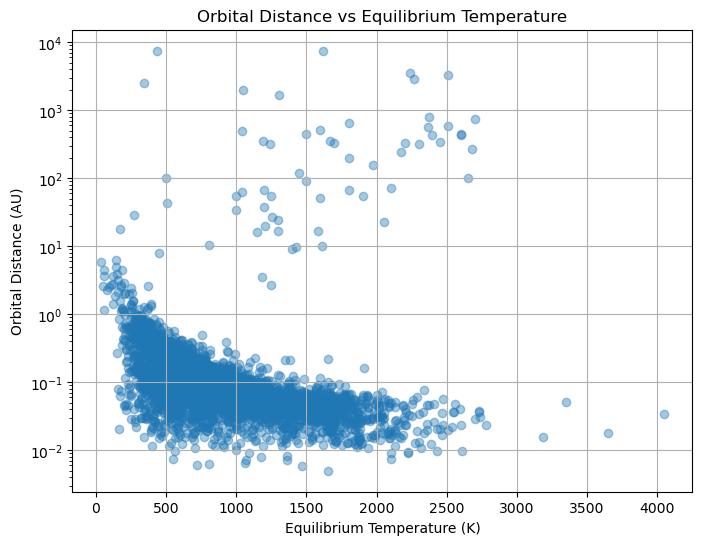

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Equilibrium Temperature [K]"],
    df["Orbit Semi-Major Axis [au]"],
    alpha=0.4
)

plt.yscale("log")

plt.title("Orbital Distance vs Equilibrium Temperature")
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Orbital Distance (AU)")

plt.grid(True)
plt.show()

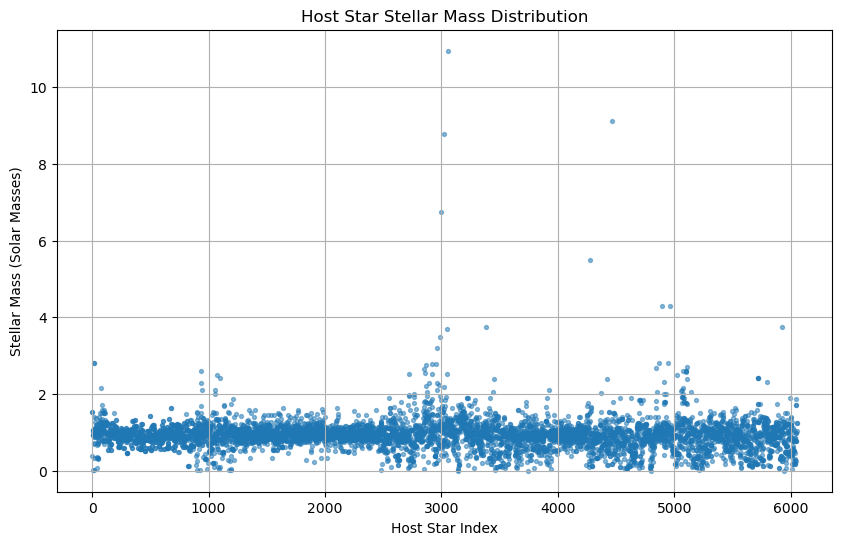

In [25]:
stellar_mass = pd.to_numeric(df["Stellar Mass [Solar mass]"], errors="coerce")

plt.figure(figsize=(10,6))

plt.scatter(
    range(len(stellar_mass.dropna())),
    stellar_mass.dropna(),
    alpha=0.5,
    s=8
)

plt.title("Host Star Stellar Mass Distribution")
plt.xlabel("Host Star Index")
plt.ylabel("Stellar Mass (Solar Masses)")

plt.grid(True)
plt.show()

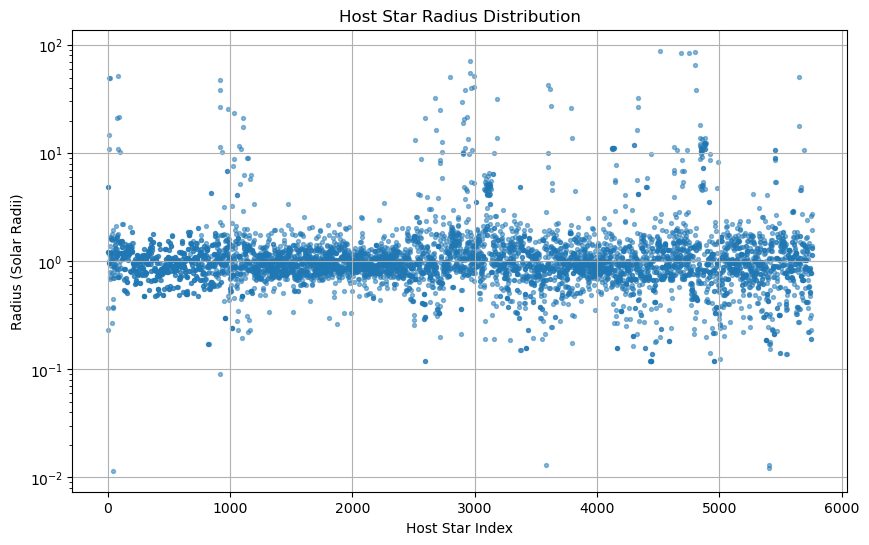

In [26]:
stellar_radius = pd.to_numeric(df["Stellar Radius [Solar Radius]"], errors="coerce")

plt.figure(figsize=(10,6))

plt.scatter(
    range(len(stellar_radius.dropna())),
    stellar_radius.dropna(),
    alpha=0.5,
    s=8
)

plt.yscale("log")

plt.title("Host Star Radius Distribution")
plt.xlabel("Host Star Index")
plt.ylabel("Radius (Solar Radii)")

plt.grid(True)
plt.show()

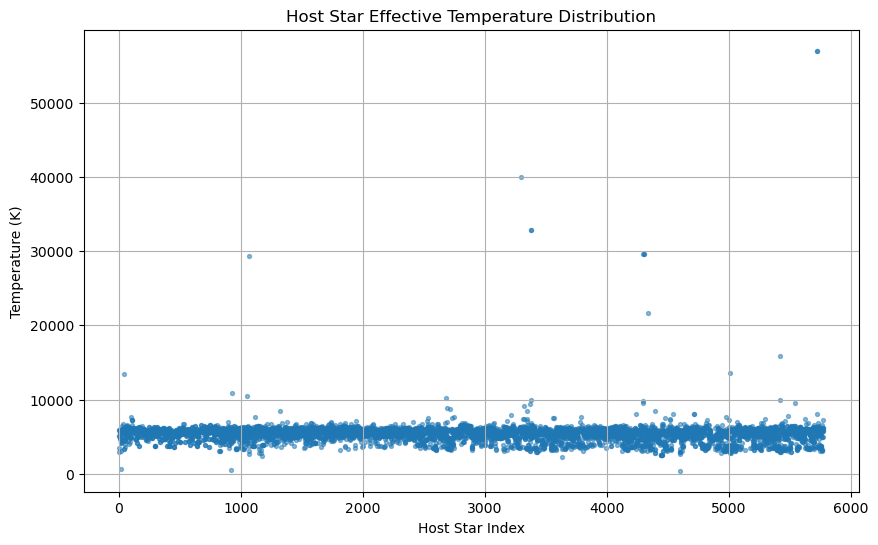

In [27]:
temp = pd.to_numeric(df["Stellar Effective Temperature [K]"], errors="coerce")

plt.figure(figsize=(10,6))

plt.scatter(
    range(len(temp.dropna())),
    temp.dropna(),
    alpha=0.5,
    s=8
)

plt.title("Host Star Effective Temperature Distribution")
plt.xlabel("Host Star Index")
plt.ylabel("Temperature (K)")

plt.grid(True)
plt.show()

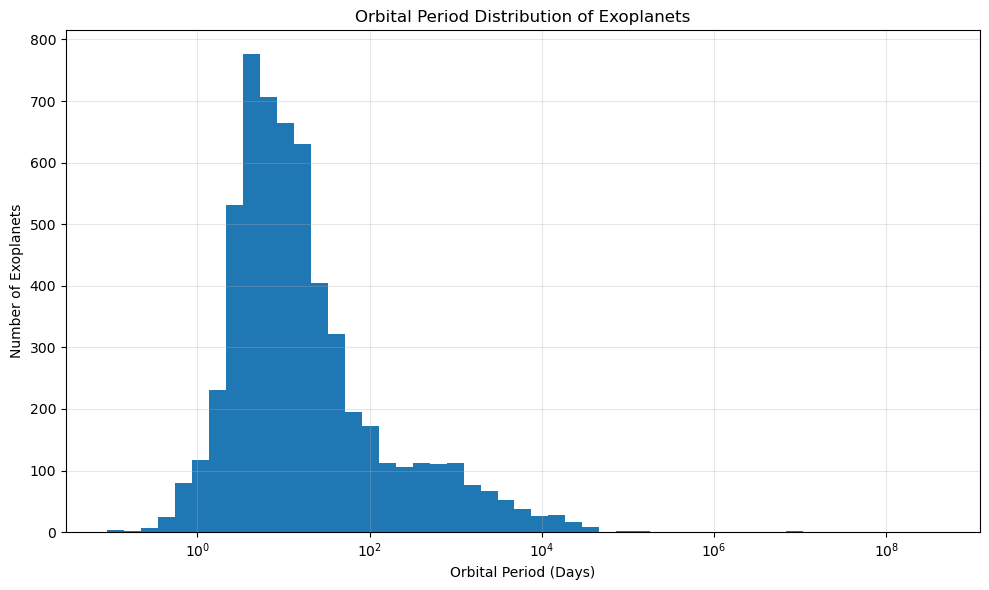

In [28]:
period=pd.to_numeric(df["Orbital Period [Days]"], errors="coerce")
period=period[period > 0]

plt.figure(figsize=(10,6))

bins = np.logspace(
    np.log10(period.min()),
    np.log10(period.max()),
    50
)

plt.hist(period, bins=bins)

plt.xscale("log")

plt.title("Orbital Period Distribution of Exoplanets")
plt.xlabel("Orbital Period (Days)")
plt.ylabel("Number of Exoplanets")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

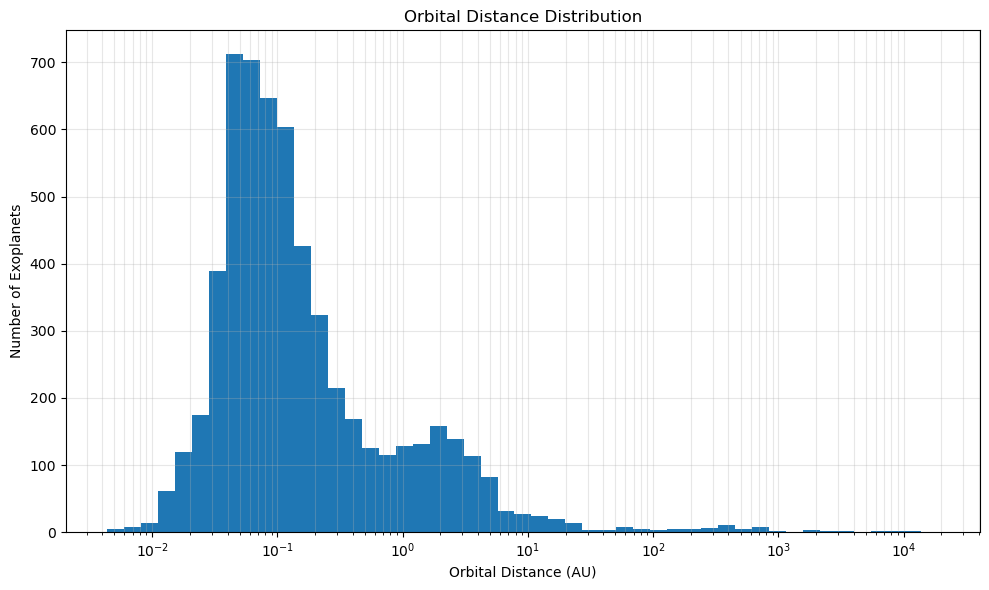

In [29]:
distance=pd.to_numeric(df["Orbit Semi-Major Axis [au]"], errors="coerce")
distance=distance[distance > 0]

plt.figure(figsize=(10,6))

bins = np.logspace(
    np.log10(distance.min()),
    np.log10(distance.max()),
    50
)

plt.hist(distance, bins=bins)

plt.xscale("log")

plt.title("Orbital Distance Distribution")
plt.xlabel("Orbital Distance (AU)")
plt.ylabel("Number of Exoplanets")

plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()